In [1]:
import numpy as np
from src import util

from src.linear_model import LinearModel

In [2]:
class LogisticRegression(LinearModel):
    """Logistic regression with Newton's Method as the solver.

    Example usage:
        > clf = LogisticRegression()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """
    def fit(self, x, y):
        """Run Newton's Method to minimize J(theta) for logistic regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        m,n=x.shape
        self.theta=np.zeros(n)
        def sigmoid(z):
            return 1/(1+np.e**(-z))

        def gradient(y,x,theta):
            return -1/len(y)*x.T@(y-sigmoid(x@theta))+theta*1e-5  
        def hessian(x,theta):
            m = x.shape[0]
            h=sigmoid(x@theta)
            h = np.clip(h, 1e-15, 1 - 1e-15)
            S = np.diag(h * (1 - h))
            return (1/m) * x.T@S@x+1e-5 * np.eye(x.shape[1])
        theta_pr=np.array(self.theta)+1
        while np.linalg.norm(self.theta-theta_pr,ord=1)>=self.eps:
            theta_pr=np.copy(self.theta)
            self.theta=self.theta- np.linalg.inv(hessian(x,self.theta))@gradient(y,x,self.theta)
            #print(self.theta)
        

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        return (0.5<=1/(1+np.exp(-(x @ self.theta)))).astype(int)

In [3]:
x_train, y_train = util.load_dataset("data/ds1_train.csv", add_intercept=True)
x_val, y_val = util.load_dataset("data/ds1_valid.csv", add_intercept=True)

In [4]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_predictions=lr.predict(x_val)
f"accuracy of logistic regression: {(lr_predictions==y_val).sum()/len(y_val)*100}%"

'accuracy of logistic regression: 90.0%'

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
def plot_line_with_data(x,y,theta,title):
    fig,ax=plt.subplots()
    sns.scatterplot(x=x[:,1],y=x[:,2],hue=y)
    def calculate_x2(x1,theta):
        return -(theta[0]+theta[1]*x1)/theta[2]
    x_min=np.min(x[:,1])
    x_max=np.max(x[:,1])
    
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    plt.plot([x_min,x_max ], [calculate_x2(x_min,theta), calculate_x2(x_max,theta)], linewidth=2,color='red')
    plt.show()

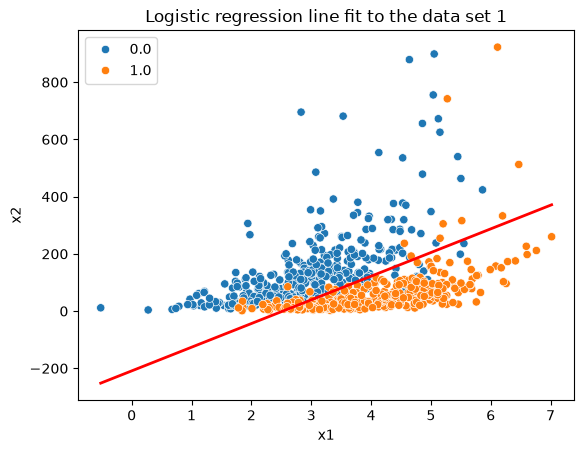

In [7]:
plot_line_with_data(x_train,y_train,lr.theta,"Logistic regression line fit to the data set 1")

In [8]:
class GDA(LinearModel):
    """Gaussian Discriminant Analysis.

    Example usage:
        > clf = GDA()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def fit(self, x, y):
        """Fit a GDA model to training set given by x and y.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).

        Returns:
            theta: GDA model parameters.
        """
        def calculate_phi(y):
            m=len(y)
            return np.sum(y==1)/m
        def mi(x,y,sign):
            return ((y==sign)@x)/(y==sign).sum()
        def calculate_sigma(x,y,mi1,mi0):
            
            x1 = x[y == 1]
            x0 = x[y == 0]
            sum1 = (x1 - mi1).T @ (x1 - mi1)
            sum0 = (x0 - mi0).T @ (x0 - mi0)
            return (sum1 + sum0) / len(y)
            # x1=((y==1)*x.T).T
            # x0=((y==0)*x.T).T
            # sum1=(x1-mi1).T@(x1-mi1)
            # sum0=(x0-mi0).T@(x0-mi0)
            # return (sum1+sum0)/len(y)
        self.n=x.shape[1]
        self.mi0=mi(x,y,0)
        self.mi1=mi(x,y,1)
        self.sigma=calculate_sigma(x,y,self.mi1,self.mi0)
        self.phi=calculate_phi(y)
        self.sigma_inv=np.linalg.inv(self.sigma)
        # alternative way to determine predictions
        def theta0(sigma_inv,mi1,mi0,phi):
            
            return 1/2*(mi0.T@sigma_inv@mi0-mi1.T@sigma_inv@mi1)-np.log(1/phi-1)
        self.theta=np.insert(np.linalg.inv(self.sigma)@(self.mi1-self.mi0),0,theta0(self.sigma_inv,self.mi1,self.mi0,self.phi))
        
    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        const=-0.5*self.n*np.log(np.pi)-0.5*np.log(np.linalg.det(self.sigma))
        prob0=const+np.sum(-1/2*(x-self.mi0)@np.linalg.inv(self.sigma)@(x-self.mi0).T,axis=1)+np.log(self.phi)
        prob1=const+np.sum(-1/2*(x-self.mi1)@np.linalg.inv(self.sigma)@(x-self.mi1).T,axis=1)+np.log(1-self.phi)
        return np.argmax([prob0,prob1],axis=0)


In [9]:
gda = GDA()
gda.fit(x_train[:,1:], y_train)
gda_predictions=gda.predict(x_val[:,1:])
f"accuracy of GDA: {(gda_predictions==y_val).sum()/len(y_val)*100}%"

'accuracy of GDA: 84.0%'

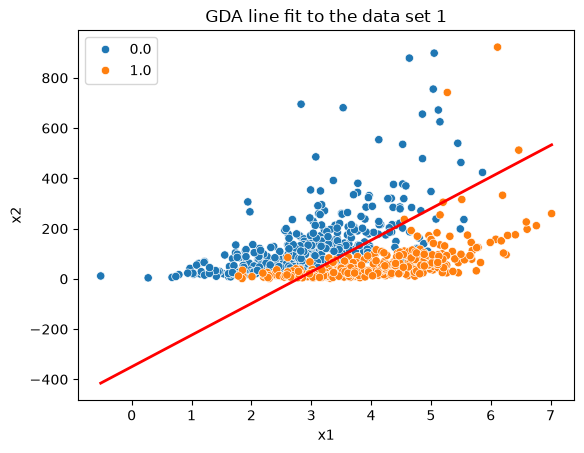

In [10]:

plot_line_with_data(x_train,y_train,gda.theta,"GDA line fit to the data set 1")

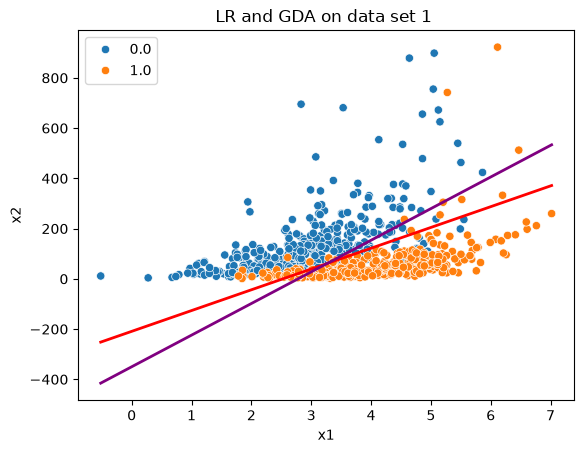

In [11]:
ax,fig=plt.subplots()
sns.scatterplot(x=x_train[:,1],y=x_train[:,2],hue=y_train)
def calculate_x2(x,theta):
    return -(theta[0]+theta[1]*x)/theta[2]
x_min=np.min(x_train[:,1])
x_max=np.max(x_train[:,1])
fig.set_xlabel("x1")
fig.set_ylabel("x2")
fig.set_title("LR and GDA on data set 1 ")
plt.plot([x_min,x_max ], [calculate_x2(x_min,lr.theta), calculate_x2(x_max,lr.theta)], linewidth=2,color='red',label='logistic regression')
plt.plot([x_min,x_max ], [calculate_x2(x_min,gda.theta), calculate_x2(x_max,gda.theta)], linewidth=2,color='purple',label="gda")
plt.show()

In [12]:
x_train2, y_train2 = util.load_dataset("data/ds2_train.csv", add_intercept=True)
x_val2, y_val2 = util.load_dataset("data/ds2_valid.csv", add_intercept=True)

In [13]:

lr2 = LogisticRegression()
lr2.fit(x_train2, y_train2)
lr2_predictions=lr2.predict(x_val2)
print(lr2_predictions)
print(y_val2)
f"accuracy of logistic regression: {(lr2_predictions==y_val2).sum()/len(y_val2)*100}%"

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


'accuracy of logistic regression: 91.0%'

In [14]:
gda2 = GDA()
gda2.fit(x_train2[:,1:], y_train2)
gda2_predictions=gda2.predict(x_val2[:,1:])
f"accuracy of GDA: {(gda2_predictions==y_val2).sum()/len(y_val2)*100}%"

'accuracy of GDA: 91.0%'

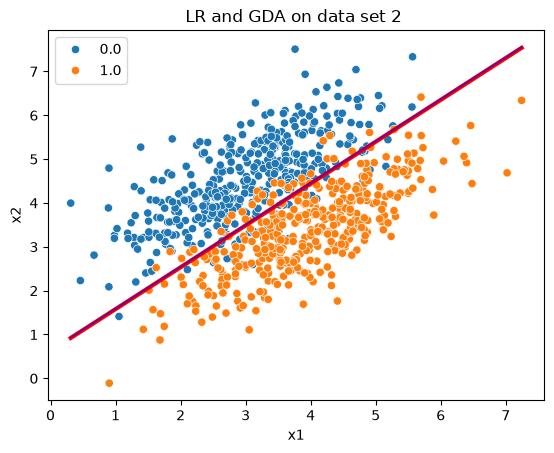

In [15]:
fig,ax=plt.subplots()
sns.scatterplot(x=x_train2[:,1],y=x_train2[:,2],hue=y_train2)
def calculate_x2(x,theta):
    return -(theta[0]+theta[1]*x)/theta[2]
x_min=np.min(x_train2[:,1])
x_max=np.max(x_train2[:,1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("LR and GDA on data set 2 ")
plt.plot([x_min,x_max ], [calculate_x2(x_min,lr2.theta), calculate_x2(x_max,lr2.theta)], linewidth=3,color='red',label='logistic regression')
plt.plot([x_min,x_max ], [calculate_x2(x_min,gda2.theta), calculate_x2(x_max,gda2.theta)], linewidth=1.5,color='purple',label="gda")
plt.show()

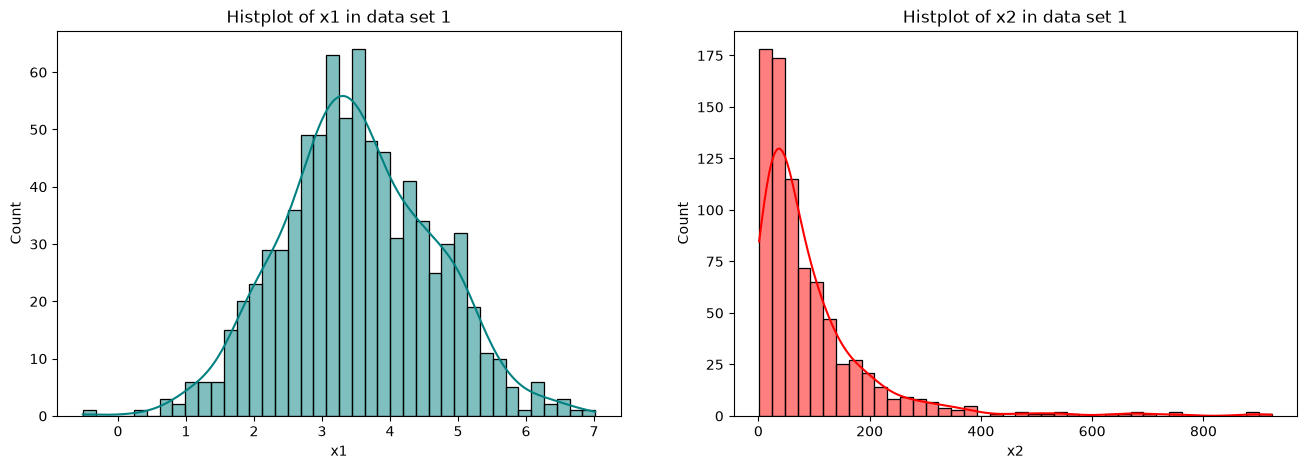

In [16]:
fig, axs = plt.subplots(1,2,figsize=(16,5))
axs[0].set_title("Histplot of x1 in data set 1")
axs[0].set_xlabel("x1")
axs[1].set_title("Histplot of x2 in data set 1")
axs[1].set_xlabel("x2")
sns.histplot(x_train[:,1], kde=True, bins=40, color="teal",ax=axs[0])
sns.histplot(x_train[:,2], kde=True, bins=40, color="red",ax=axs[1])
plt.show()

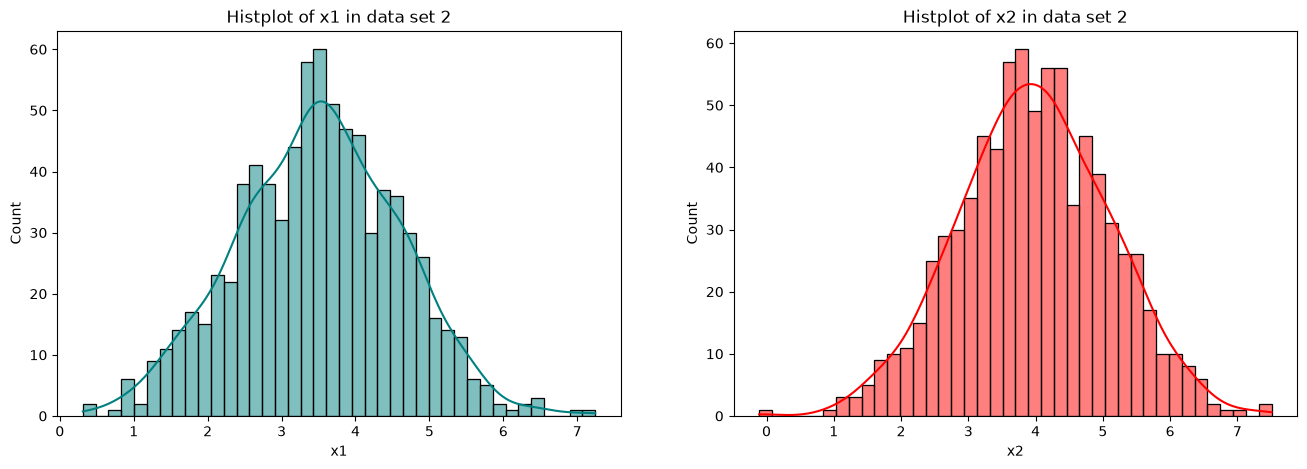

In [17]:
fig, axs = plt.subplots(1,2,figsize=(16,5))
axs[0].set_title("Histplot of x1 in data set 2")
axs[0].set_xlabel("x1")
axs[1].set_title("Histplot of x2 in data set 2")
axs[1].set_xlabel("x2")
sns.histplot(x_train2[:,1], kde=True, bins=40, color="teal",ax=axs[0])
sns.histplot(x_train2[:,2], kde=True, bins=40, color="red",ax=axs[1])
plt.show()

## Result interpretation
GDA performs better on second data set. It can be seen in the plots above, that both features in data set 2 have distribution similiar to gaussian. On the contrary x2 feature in first data set is nowhere near normall distribution, which is the reason for worse performance on this data set.

In [18]:
x_train[:,2].min() # so no need to use log1p

np.float64(1.4032702290626504)

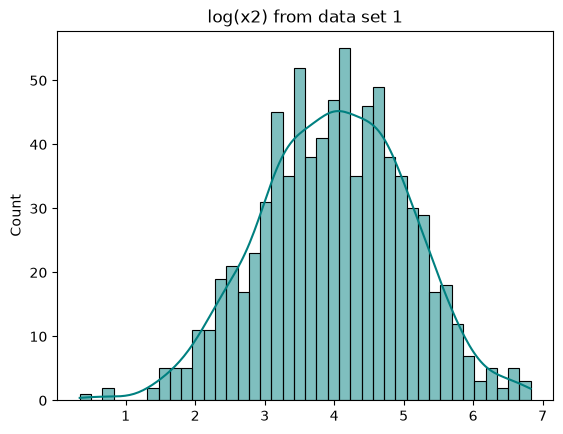

In [19]:
fig,ax=plt.subplots()
ax.set_title("log(x2) from data set 1")
sns.histplot(np.log(x_train[:,2]), kde=True, bins=40, color="teal")
plt.show()

In [20]:
x_train_adj=np.copy(x_train)
x_train_adj[:,2]=np.log(x_train[:,2])
x_val_adj=np.copy(x_val)
x_val_adj[:,2]=np.log(x_val[:,2])

In [21]:
gda.fit(x_train_adj[:,1:], y_train)
gda_adj_predictions=gda.predict(x_val_adj[:,1:])
f"accuracy of GDA: {(gda_adj_predictions==y_val).sum()/len(y_val)*100}%"

'accuracy of GDA: 92.0%'

Accuracy improved to 92% surpassing logistic regression! 